In [152]:
import matplotlib.pyplot as plt
import pandas as pd
import math, numpy as np
import re
import seaborn as sns

In [153]:
time_cache = '../data/outs/03272/all_time_cache.csv'
mem = '../data/outs/03272/all_mem.csv'

try:
    df_tcache = pd.read_csv(time_cache, sep=' ')
    df_mem = pd.read_csv(mem, sep=' ')
    print("Dados lidos com sucesso!")

except FileNotFoundError:
    print(f"Erro: Arquivo não encontrado!")

Erro: Arquivo não encontrado!


In [154]:
df_tcache.dtypes

nome           object
n               int64
m               int64
c               int64
insert          int64
extractMin      int64
dk              int64
bkmp            int64
fila           object
cpu_time        int64
wall_time       int64
l1_ac           int64
l1_miss         int64
llc_ac          int64
llc_miss        int64
cycles          int64
inst            int64
dtlb            int64
page_faults     int64
branch_inst     int64
branch_miss     int64
dtype: object

In [155]:
df_mem.dtypes

nome    object
n        int64
m        int64
c        int64
fila    object
mem      int64
dtype: object

In [156]:
# selecionar todos que não são MEM

df_tcache = df_tcache[~df_tcache["nome"].str.startswith("MEM")]
df_mem = df_mem[~df_mem["nome"].str.startswith("MEM")]

# Uso de memória

In [157]:
# pivot = df_mem.pivot_table(
#     index="n",
#     columns="fila",
#     values="mem",
#     aggfunc="first"
# )

# c_vals = pivot.index.to_list()
# filas = pivot.columns.to_list()

# x = np.arange(len(c_vals))
# width = 0.8 / len(filas)

# # 🎨 cores por número da fila (LVBQ)
# colors = {
#     "1": "tab:red",
#     "2": "tab:orange",
#     "3": "tab:olive",
#     "4": "tab:green",
#     "5": "tab:blue",
#     "6": "tab:purple",
# }

# plt.figure(figsize=(12, 6))

# for i, fila in enumerate(filas):

#     # ===== HEAPS (cores exclusivas) =====
#     if "BINH" in fila:
#         color = "black"
#         hatch = "xx"
        
#     elif "FIBH" in fila:
#         color = "gold"
#         hatch = ".."

#     # ===== LVBQ / LVBQDK =====
#     else:
#         # extrai número da fila (1–6)
#         m = re.match(r"\d+", fila)
#         num = m.group() if m else None

#         color = colors.get(num, "tab:gray")

#         # padrão para DK
#         hatch = "//" if "LVBQDK" in fila else None

#     plt.bar(
#         x + i * width,
#         pivot[fila].values,
#         width,
#         label=fila,
#         color=color,
#         hatch=hatch,
#         edgecolor="black"
#     )

# plt.xticks(x + width * len(filas) / 2, c_vals)
# plt.xlabel("n")
# plt.ylabel("mem")
# plt.title("Memória por n e fila")
# plt.legend(bbox_to_anchor=(1.05, 1))

# plt.tight_layout()
# plt.show()

In [158]:
# rank = (
#     df_mem
#     .sort_values(['nome', 'mem'])
#     .groupby('nome')
#     .head(6)
# )

# rank['rank'] = rank.groupby('nome').cumcount() + 1

# resultado = rank.pivot(
#     index='nome',
#     columns='rank',
#     values=['fila', 'mem']
# )

# resultado.columns = [f'{col}{rank}' for col, rank in resultado.columns]

# resultado = resultado.reset_index()

# resultado = resultado.sort_values('mem1')

# resultado

# Tempo de execução

In [159]:
df_tcache.head()

,nome,n,m,c,insert,extractMin,dk,bkmp,fila,cpu_time,...,l1_ac,l1_miss,llc_ac,llc_miss,cycles,inst,dtlb,page_faults,branch_inst,branch_miss
840,NY,264346,733846,36946,298589,298589,0,937510,1LVBQ,71,...,192886692,2912576,311365,137482,170035462,393036406,12993,0,73606796,744980
841,NY,264346,733846,36946,298623,298623,0,752925,1LVBQ,72,...,189253542,2879233,310203,131798,170093646,393110958,14727,0,73909871,743864
842,NY,264346,733846,36946,298996,298996,0,722324,1LVBQ,72,...,190677026,2837317,308026,128696,166774976,394402649,14463,0,73892604,744334
843,NY,264346,733846,36946,298853,298853,0,775423,1LVBQ,71,...,189928949,2852688,308129,134511,166192146,389564875,13217,0,73397328,743063
844,NY,264346,733846,36946,299101,299101,0,896861,1LVBQ,72,...,191497332,2882155,308393,136162,170218966,397655180,12168,0,73301714,739324


In [160]:
df_time = df_tcache[
    ['nome', 'n', 'c', 'fila', 'cpu_time', 'wall_time']
].copy()
df_time

,nome,n,c,fila,cpu_time,wall_time
840,NY,264346,36946,1LVBQ,71,71
841,NY,264346,36946,1LVBQ,72,72
842,NY,264346,36946,1LVBQ,72,72
843,NY,264346,36946,1LVBQ,71,71
844,NY,264346,36946,1LVBQ,72,72
...,...,...,...,...,...,...
2515,USA,23947347,368855,FIBH,20124,20126
2516,USA,23947347,368855,FIBH,19734,19736
2517,USA,23947347,368855,FIBH,18959,18960
2518,USA,23947347,368855,FIBH,19688,19689


In [161]:
df_time["wall_cpu_ratio"] = df_time["wall_time"] / df_time["cpu_time"]
print("Min ratio", df_time["wall_cpu_ratio"].min())
print("Max ratio", df_time["wall_cpu_ratio"].max())

Min ratio 0.9906542056074766
Max ratio 1.0091743119266054


Logo, CPU Bound

In [162]:
df_cpu = df_tcache[
    ['nome', 'n', 'c', 'fila', 'cpu_time']
].copy()
df_cpu = (
    df_cpu.groupby(['nome', 'fila'], as_index=False)
      .agg(
           cpu_mean=('cpu_time', 'mean'),
           cpu_std =('cpu_time', 'std'),
           cpu_var =('cpu_time', 'var'),
           n=('n', 'first'),
      )
)
df_cpu['cpu_cv'] = df_cpu['cpu_std'] / df_cpu['cpu_mean']
df_cpu

,nome,fila,cpu_mean,cpu_std,cpu_var,n,cpu_cv
0,BAY,1LVBQ,89.5,0.849837,0.722222,321270,0.009495
1,BAY,1LVBQDK,64.5,0.849837,0.722222,321270,0.013176
2,BAY,2LVBQ,97.3,1.828782,3.344444,321270,0.018795
3,BAY,2LVBQDK,70.5,0.849837,0.722222,321270,0.012054
4,BAY,3LVBQ,86.5,0.527046,0.277778,321270,0.006093
...,...,...,...,...,...,...,...
163,W,5LVBQDK,1861.9,29.148852,849.655556,6262104,0.015655
164,W,6LVBQ,2031.5,31.443954,988.722222,6262104,0.015478
165,W,6LVBQDK,1888.1,21.031458,442.322222,6262104,0.011139
166,W,BINH,2644.5,61.783223,3817.166667,6262104,0.023363


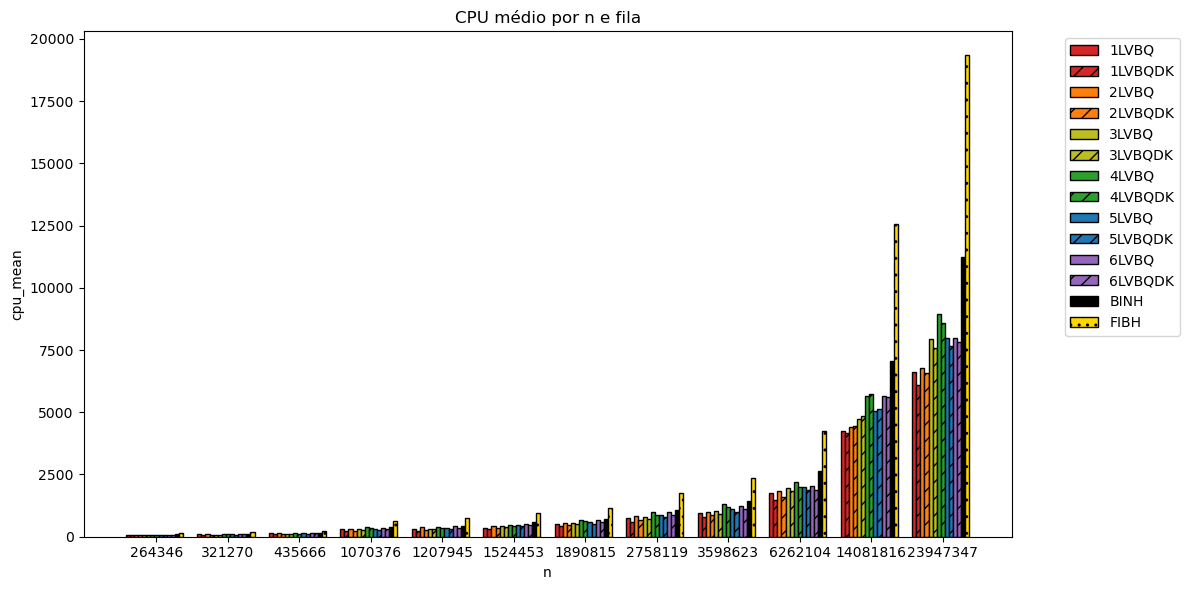

In [163]:
pivot = df_cpu.pivot_table(
    index="n",
    columns="fila",
    values="cpu_mean",
    aggfunc="first"
)

n_vals = pivot.index.to_list()
filas = pivot.columns.to_list()

x = np.arange(len(n_vals))
width = 0.8 / len(filas)

# 🎨 cores por número da fila (LVBQ)
colors = {
    "1": "tab:red",
    "2": "tab:orange",
    "3": "tab:olive",
    "4": "tab:green",
    "5": "tab:blue",
    "6": "tab:purple",
}

plt.figure(figsize=(12, 6))

for i, fila in enumerate(filas):

    # ===== HEAPS (se existirem) =====
    if "BINH" in fila:
        color = "black"
        hatch = "xx"
        
    elif "FIBH" in fila:
        color = "gold"
        hatch = ".."

    # ===== LVBQ / LVBQDK =====
    else:
        m = re.match(r"\d+", fila)
        num = m.group() if m else None

        color = colors.get(num, "tab:gray")

        # DK com padrão
        hatch = "//" if "LVBQDK" in fila else None

    plt.bar(
        x + i * width,
        pivot[fila].values,
        width,
        label=fila,
        color=color,
        hatch=hatch,
        edgecolor="black"
    )

plt.xticks(x + width * len(filas) / 2, n_vals)
plt.xlabel("n")
plt.ylabel("cpu_mean")
plt.title("CPU médio por n e fila")
plt.legend(bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

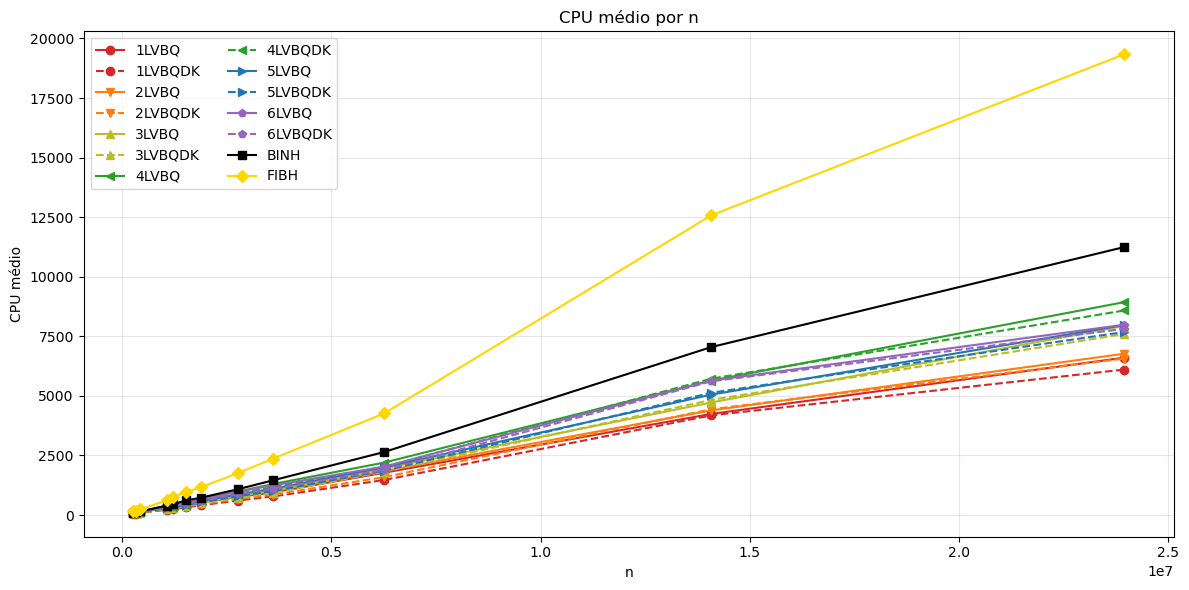

In [164]:

# selecionar BINH, Fibonacci e todas LVBQ (1–6) com ou sem DK
mask = (
    (df_cpu["fila"] == "BINH") |
    (df_cpu["fila"] == "FIBH") |  # adiciona Fibonacci
    (df_cpu["fila"].str.match(r"[1-6]LVBQ(DK)?"))
)

df_sel = df_cpu[mask].copy()

# ordenar por n (ESSENCIAL para gráfico de linhas)
df_sel = df_sel.sort_values("n")

# ordem consistente das curvas
filas_sel = sorted(df_sel["fila"].unique())

# 🔹 marcadores por nível LVBQ
marcadores_nivel = {
    1: "o",   # círculo
    2: "v",   # triângulo para baixo
    3: "^",   # triângulo para cima
    4: "<",   # triângulo para esquerda
    5: ">",   # triângulo para direita
    6: "p",   # pentágono
}

plt.figure(figsize=(12, 6))

for fila in filas_sel:
    dados = df_sel[df_sel["fila"] == fila]

    if dados.empty:
        continue

    # ===== BINH =====
    if fila == "BINH":
        color = "black"
        linestyle = "-"
        marker = "s"

    # ===== FIBH (Fibonacci) =====
    elif fila == "FIBH":
        color = "gold"
        linestyle = "-"
        marker = "D"  # diamante

    # ===== LVBQ / LVBQDK =====
    else:
        nivel = int(re.match(r"\d+", fila).group())

        # 🎨 cor por nível (1–6)
        cores = {
            1: "tab:red",
            2: "tab:orange",
            3: "tab:olive",
            4: "tab:green",
            5: "tab:blue",
            6: "tab:purple",
        }
        color = cores[nivel]

        # DK → tracejado
        linestyle = "--" if "DK" in fila else "-"

        # marcador por nível
        marker = marcadores_nivel[nivel]

    plt.plot(
        dados["n"],
        dados["cpu_mean"],
        label=fila,
        color=color,
        linestyle=linestyle,
        marker=marker
    )

plt.xlabel("n")
plt.ylabel("CPU médio")
plt.title("CPU médio por n")
plt.legend(ncol=2)  # legenda mais compacta
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

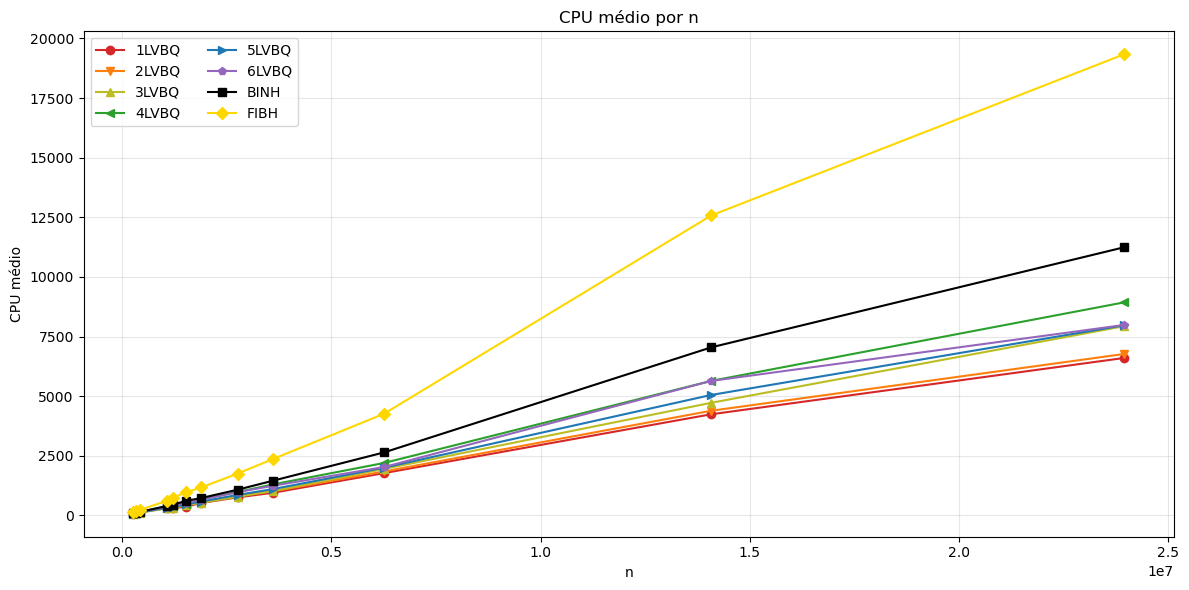

In [165]:
# 🎯 selecionar BINH, Fibonacci e todas LVBQ (1–6) **sem DK**
mask = (
    (df_cpu["fila"] == "BINH") |
    (df_cpu["fila"] == "FIBH") |  # adiciona Fibonacci
    (df_cpu["fila"].str.match(r"[1-6]LVBQ$"))  # somente LVBQ sem DK
)

df_sel = df_cpu[mask].copy()

# ordenar por n (ESSENCIAL para gráfico de linhas)
df_sel = df_sel.sort_values("n")

# ordem consistente das curvas
filas_sel = sorted(df_sel["fila"].unique())

# 🔹 marcadores por nível LVBQ
marcadores_nivel = {
    1: "o",   # círculo
    2: "v",   # triângulo para baixo
    3: "^",   # triângulo para cima
    4: "<",   # triângulo para esquerda
    5: ">",   # triângulo para direita
    6: "p",   # pentágono
}

plt.figure(figsize=(12, 6))

for fila in filas_sel:
    dados = df_sel[df_sel["fila"] == fila]

    if dados.empty:
        continue

    # ===== BINH =====
    if fila == "BINH":
        color = "black"
        linestyle = "-"
        marker = "s"

    # ===== FIBH (Fibonacci) =====
    elif fila == "FIBH":
        color = "gold"
        linestyle = "-"
        marker = "D"  # diamante

    # ===== LVBQ simples (1–6) =====
    else:
        nivel = int(re.match(r"\d+", fila).group())

        # 🎨 cor por nível (1–6)
        cores = {
            1: "tab:red",
            2: "tab:orange",
            3: "tab:olive",
            4: "tab:green",
            5: "tab:blue",
            6: "tab:purple",
        }
        color = cores[nivel]

        linestyle = "-"  # todas LVBQ simples são sólidas
        marker = marcadores_nivel[nivel]

    plt.plot(
        dados["n"],
        dados["cpu_mean"],
        label=fila,
        color=color,
        linestyle=linestyle,
        marker=marker
    )

plt.xlabel("n")
plt.ylabel("CPU médio")
plt.title("CPU médio por n")
plt.legend(ncol=2)  # legenda mais compacta
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

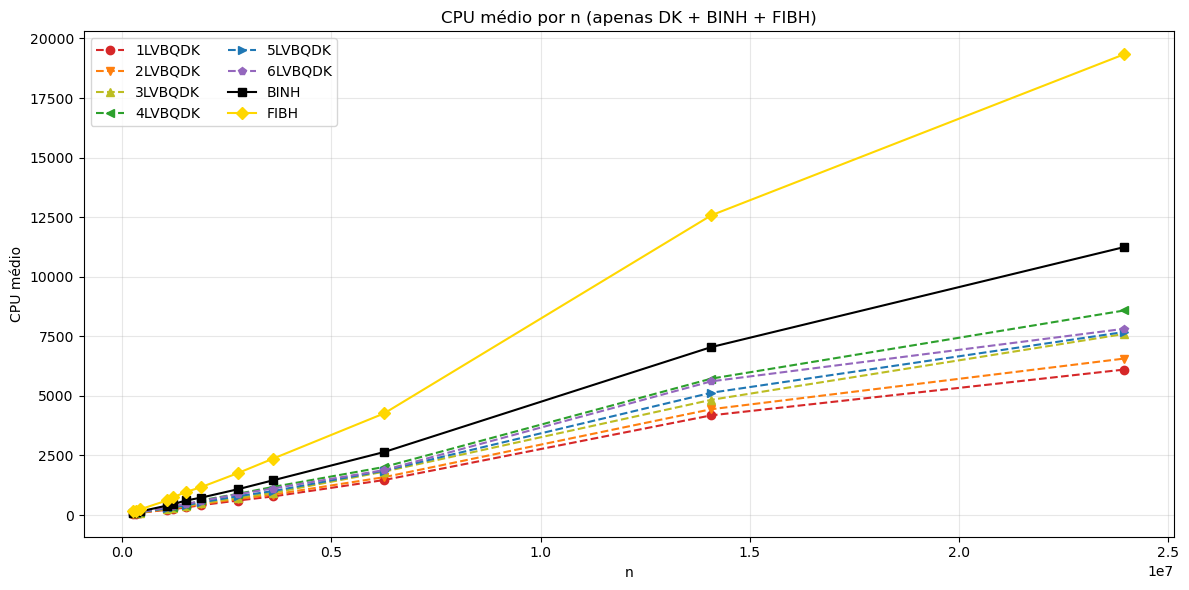

In [166]:
# 🎯 selecionar BINH, Fibonacci e todas LVBQ (1–6) **apenas DK**
mask = (
    (df_cpu["fila"] == "BINH") |
    (df_cpu["fila"] == "FIBH") |  # adiciona Fibonacci
    (df_cpu["fila"].str.match(r"[1-6]LVBQDK$"))  # somente LVBQ DK
)

df_sel = df_cpu[mask].copy()

# ordenar por n (ESSENCIAL para gráfico de linhas)
df_sel = df_sel.sort_values("n")

# ordem consistente das curvas
filas_sel = sorted(df_sel["fila"].unique())

# 🔹 marcadores por nível LVBQ
marcadores_nivel = {
    1: "o",   # círculo
    2: "v",   # triângulo para baixo
    3: "^",   # triângulo para cima
    4: "<",   # triângulo para esquerda
    5: ">",   # triângulo para direita
    6: "p",   # pentágono
}

plt.figure(figsize=(12, 6))

for fila in filas_sel:
    dados = df_sel[df_sel["fila"] == fila]

    if dados.empty:
        continue

    # ===== BINH =====
    if fila == "BINH":
        color = "black"
        linestyle = "-"
        marker = "s"

    # ===== FIBH (Fibonacci) =====
    elif fila == "FIBH":
        color = "gold"
        linestyle = "-"
        marker = "D"  # diamante

    # ===== LVBQ DK (1–6) =====
    else:
        nivel = int(re.match(r"\d+", fila).group())

        # 🎨 cor por nível (1–6)
        cores = {
            1: "tab:red",
            2: "tab:orange",
            3: "tab:olive",
            4: "tab:green",
            5: "tab:blue",
            6: "tab:purple",
        }
        color = cores[nivel]

        linestyle = "--"  # DK → tracejado
        marker = marcadores_nivel[nivel]

    plt.plot(
        dados["n"],
        dados["cpu_mean"],
        label=fila,
        color=color,
        linestyle=linestyle,
        marker=marker
    )

plt.xlabel("n")
plt.ylabel("CPU médio")
plt.title("CPU médio por n (apenas DK + BINH + FIBH)")
plt.legend(ncol=2)  # legenda mais compacta
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Outras métricas

In [167]:
df_tcache.head(10)

,nome,n,m,c,insert,extractMin,dk,bkmp,fila,cpu_time,...,l1_ac,l1_miss,llc_ac,llc_miss,cycles,inst,dtlb,page_faults,branch_inst,branch_miss
840,NY,264346,733846,36946,298589,298589,0,937510,1LVBQ,71,...,192886692,2912576,311365,137482,170035462,393036406,12993,0,73606796,744980
841,NY,264346,733846,36946,298623,298623,0,752925,1LVBQ,72,...,189253542,2879233,310203,131798,170093646,393110958,14727,0,73909871,743864
842,NY,264346,733846,36946,298996,298996,0,722324,1LVBQ,72,...,190677026,2837317,308026,128696,166774976,394402649,14463,0,73892604,744334
843,NY,264346,733846,36946,298853,298853,0,775423,1LVBQ,71,...,189928949,2852688,308129,134511,166192146,389564875,13217,0,73397328,743063
844,NY,264346,733846,36946,299101,299101,0,896861,1LVBQ,72,...,191497332,2882155,308393,136162,170218966,397655180,12168,0,73301714,739324
845,NY,264346,733846,36946,298638,298638,0,1087082,1LVBQ,72,...,194406562,2904882,314646,140668,168527559,406098230,12108,0,73607496,727533
846,NY,264346,733846,36946,298755,298755,0,874379,1LVBQ,72,...,193260139,2892178,313695,129415,168682145,399200217,13811,0,74327487,754757
847,NY,264346,733846,36946,299202,299202,0,810501,1LVBQ,71,...,191339487,2918054,302183,127357,168485469,398859983,14355,0,74221353,768117
848,NY,264346,733846,36946,298954,298954,0,713236,1LVBQ,72,...,191774074,2876683,310917,130636,168837335,390832000,14587,0,73866235,749896
849,NY,264346,733846,36946,299003,299003,0,1057760,1LVBQ,72,...,193101975,2910550,307314,124846,167559740,398294605,12184,0,73939654,736399


## IPC

In [168]:
df_instc = df_tcache[
    ['nome', 'fila', 'inst', 'cycles']
].copy()

df_instc = (
    df_instc.groupby(['nome', 'fila'], as_index=False)
      .agg(
           inst_total=('inst', 'sum'),
           cycles_total=('cycles', 'sum'),
      )
)

df_instc['ipc'] = (
    df_instc['inst_total'] /
    df_instc['cycles_total'].replace(0, np.nan)
)

df_instc

,nome,fila,inst_total,cycles_total,ipc
0,BAY,1LVBQ,5099865128,2102639772,2.425458
1,BAY,1LVBQDK,3471307823,1526157422,2.274541
2,BAY,2LVBQ,6786701496,2280318395,2.976208
3,BAY,2LVBQDK,4114310724,1698665514,2.422084
4,BAY,3LVBQ,5854865485,2042345050,2.866737
...,...,...,...,...,...
163,W,5LVBQDK,98781276318,42920849518,2.301475
164,W,6LVBQ,127441312455,47593436772,2.677708
165,W,6LVBQDK,100179078982,43542856557,2.300701
166,W,BINH,163132395139,61476736171,2.653563


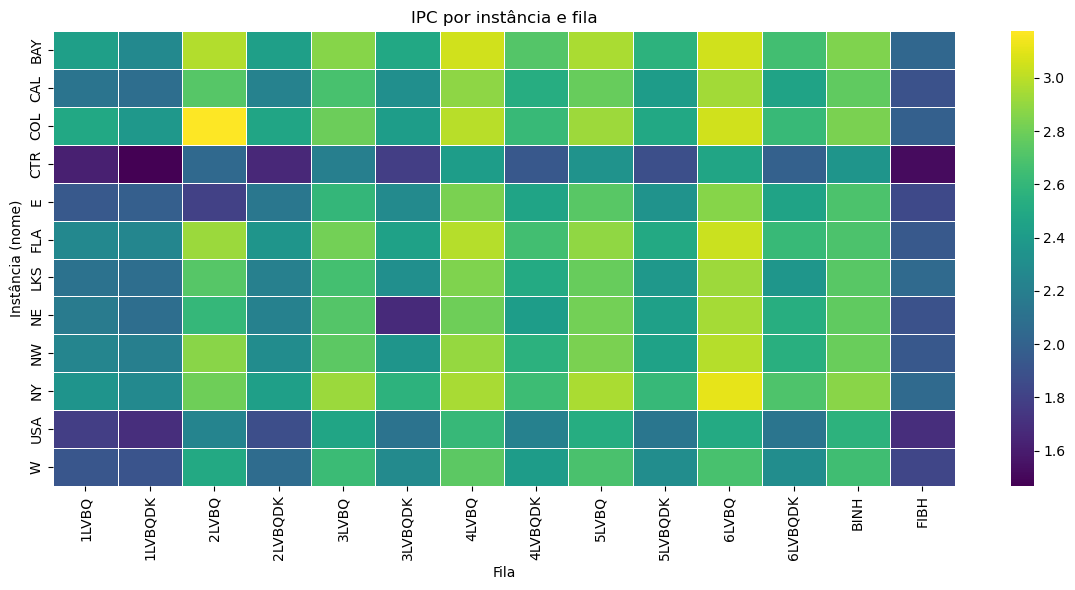

In [169]:

# ===== métrica escolhida =====
df_plot = df_instc.copy()

# opção A: LLC apenas
df_plot["miss"] = df_plot["ipc"]

# ===== pivot =====
heat = df_plot.pivot(index="nome", columns="fila", values="ipc")

# ===== plot =====
plt.figure(figsize=(12, 6))

sns.heatmap(
    heat,
    cmap="viridis",
    linewidths=0.5,
    linecolor="white"
)

plt.title("IPC por instância e fila")
plt.xlabel("Fila")
plt.ylabel("Instância (nome)")

plt.tight_layout()
plt.show()

In [170]:
df_inst = df_tcache[
    ['nome', 'fila', 'inst']
].copy()

df_inst = (
    df_inst.groupby(['nome', 'fila'], as_index=False)
      .agg(
           inst_total=('inst', 'sum'),
           inst_mean=('inst', 'mean'),
           inst_std =('inst', 'std'),
      )
)

df_inst['inst_cv'] = df_inst['inst_std'] / df_inst['inst_mean']
df_inst

,nome,fila,inst_total,inst_mean,inst_std,inst_cv
0,BAY,1LVBQ,5099865128,5.099865e+08,1.362368e+07,0.026714
1,BAY,1LVBQDK,3471307823,3.471308e+08,1.144046e+07,0.032957
2,BAY,2LVBQ,6786701496,6.786701e+08,2.107763e+07,0.031057
3,BAY,2LVBQDK,4114310724,4.114311e+08,6.808503e+06,0.016548
4,BAY,3LVBQ,5854865485,5.854865e+08,1.150025e+07,0.019642
...,...,...,...,...,...,...
163,W,5LVBQDK,98781276318,9.878128e+09,1.164597e+07,0.001179
164,W,6LVBQ,127441312455,1.274413e+10,6.570731e+07,0.005156
165,W,6LVBQDK,100179078982,1.001791e+10,1.520102e+07,0.001517
166,W,BINH,163132395139,1.631324e+10,2.353405e+08,0.014426


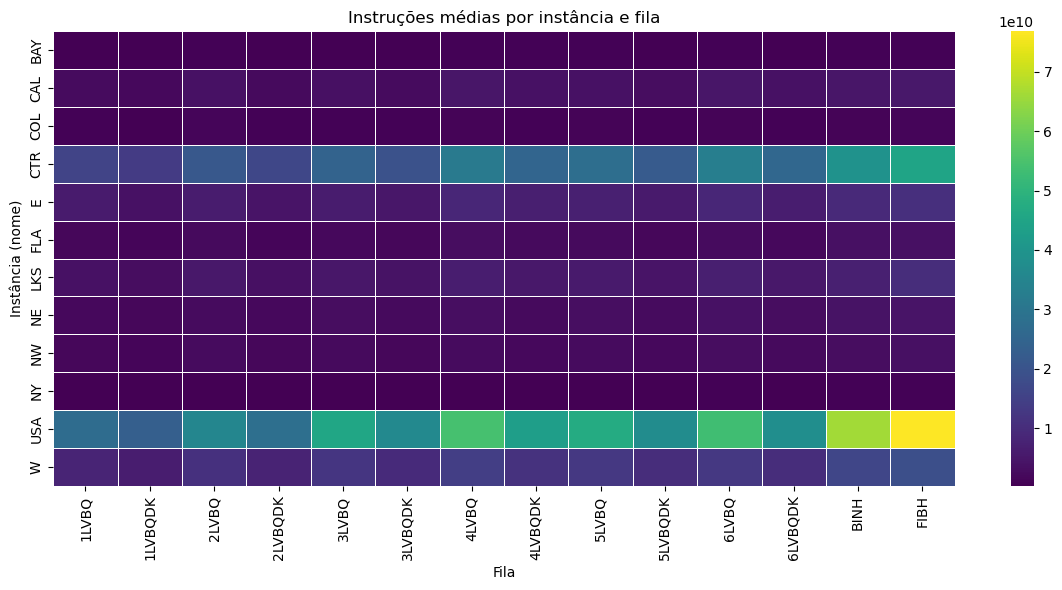

In [171]:

# ===== métrica escolhida =====
df_plot = df_inst.copy()

# opção A: LLC apenas
df_plot["miss"] = df_plot["inst_mean"]

# ===== pivot =====
heat = df_plot.pivot(index="nome", columns="fila", values="inst_mean")

# ===== plot =====
plt.figure(figsize=(12, 6))

sns.heatmap(
    heat,
    cmap="viridis",
    linewidths=0.5,
    linecolor="white"
)

plt.title("Instruções médias por instância e fila")
plt.xlabel("Fila")
plt.ylabel("Instância (nome)")

plt.tight_layout()
plt.show()

### Page fault

In [172]:
# normalizar
df_pf = df_tcache[
    ['nome', 'fila', 'inst', 'page_faults']
].copy()

inst_safe = df_pf["inst"].replace(0, np.nan)

df_pf["pf_pi"] = df_pf["page_faults"] / inst_safe

# agregar
df_pf = (
    df_pf.groupby(['nome', 'fila'], as_index=False)
      .agg(
           pf_mean=('pf_pi', 'mean'),
           pf_std =('pf_pi', 'std'),
           pf_var =('pf_pi', 'var'),
      )
)

df_pf['pf_cv'] = df_pf['pf_std'] / df_pf['pf_mean']
df_pf

,nome,fila,pf_mean,pf_std,pf_var,pf_cv
0,BAY,1LVBQ,0.000000e+00,0.000000e+00,0.000000e+00,NaN
1,BAY,1LVBQDK,1.848982e-08,5.846993e-08,3.418733e-15,3.162278
2,BAY,2LVBQ,0.000000e+00,0.000000e+00,0.000000e+00,NaN
3,BAY,2LVBQDK,0.000000e+00,0.000000e+00,0.000000e+00,NaN
4,BAY,3LVBQ,0.000000e+00,0.000000e+00,0.000000e+00,NaN
...,...,...,...,...,...,...
163,W,5LVBQDK,5.757112e-06,8.258807e-07,6.820789e-13,0.143454
164,W,6LVBQ,6.719068e-07,4.636769e-07,2.149963e-13,0.690091
165,W,6LVBQDK,5.677019e-06,8.165723e-07,6.667903e-13,0.143838
166,W,BINH,5.621633e-07,3.188810e-07,1.016851e-13,0.567239


In [173]:
# normalizar
df_dtlb = df_tcache[
    ['nome', 'fila', 'inst', 'dtlb']
].copy()

inst_safe = df_dtlb["inst"].replace(0, np.nan)

df_dtlb["dtlb_pi"] = df_dtlb["dtlb"] / inst_safe

# agregar
df_dtlb = (
    df_dtlb.groupby(['nome', 'fila'], as_index=False)
      .agg(
           dtlb_mean=('dtlb_pi', 'mean'),
           dtlb_std=('dtlb_pi', 'std'),
           dtlb_var=('dtlb_pi', 'var'),
      )
)

df_dtlb['dtlb_cv'] = df_dtlb['dtlb_std'] / df_dtlb['dtlb_mean']
df_dtlb

,nome,fila,dtlb_mean,dtlb_std,dtlb_var,dtlb_cv
0,BAY,1LVBQ,0.000041,0.000003,9.193720e-12,0.074383
1,BAY,1LVBQDK,0.000041,0.000006,3.859239e-11,0.150669
2,BAY,2LVBQ,0.000017,0.000003,6.501265e-12,0.152362
3,BAY,2LVBQDK,0.000031,0.000006,3.767592e-11,0.196064
4,BAY,3LVBQ,0.000018,0.000004,1.840749e-11,0.240156
...,...,...,...,...,...,...
163,W,5LVBQDK,0.000241,0.000043,1.873831e-09,0.179253
164,W,6LVBQ,0.000133,0.000059,3.492983e-09,0.443856
165,W,6LVBQDK,0.000234,0.000043,1.883513e-09,0.185510
166,W,BINH,0.000094,0.000022,4.737384e-10,0.231576


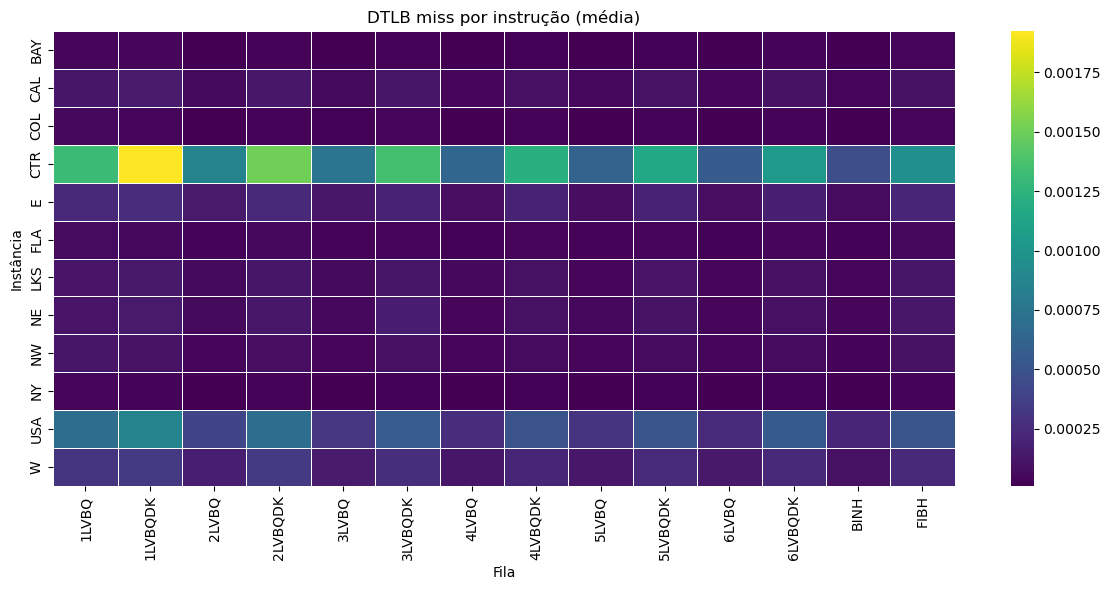

In [174]:
# ===== métrica escolhida =====
df_plot = df_dtlb.copy()

# ===== pivot =====
heat = df_dtlb.pivot(index="nome", columns="fila", values="dtlb_mean")

# ===== plot =====
plt.figure(figsize=(12, 6))

sns.heatmap(
    heat,
    cmap="viridis",
    linewidths=0.5,
    linecolor="white"
)

plt.title("DTLB miss por instrução (média)")
plt.xlabel("Fila")
plt.ylabel("Instância")

plt.tight_layout()
plt.show()

## Branch Miss Rate

In [175]:
# normalizar
df_branches = df_tcache[
    ['nome', 'fila', 'branch_miss', 'branch_inst']
].copy()
inst_safe = df_branches["branch_inst"].replace(0, np.nan)
df_branches['bm_rate'] = df_branches['branch_miss'] / inst_safe

# agregar
df_branches = (
    df_branches.groupby(['nome', 'fila'], as_index=False)
      .agg(
           bm_mean=('bm_rate', 'mean'),
           bm_std =('bm_rate', 'std'),
           bm_var =('bm_rate', 'var'),
      )
)
df_branches['bm_cv'] = df_branches['bm_std'] / df_branches['bm_mean']
df_branches

,nome,fila,bm_mean,bm_std,bm_var,bm_cv
0,BAY,1LVBQ,0.009159,0.000202,4.066206e-08,0.022017
1,BAY,1LVBQDK,0.013613,0.000451,2.031261e-07,0.033109
2,BAY,2LVBQ,0.005433,0.000137,1.885114e-08,0.025271
3,BAY,2LVBQDK,0.013032,0.000186,3.470206e-08,0.014295
4,BAY,3LVBQ,0.006913,0.000250,6.266227e-08,0.036212
...,...,...,...,...,...,...
163,W,5LVBQDK,0.012611,0.000327,1.068375e-07,0.025919
164,W,6LVBQ,0.005983,0.000230,5.294332e-08,0.038455
165,W,6LVBQDK,0.012329,0.000293,8.609293e-08,0.023800
166,W,BINH,0.013725,0.000080,6.380149e-09,0.005820


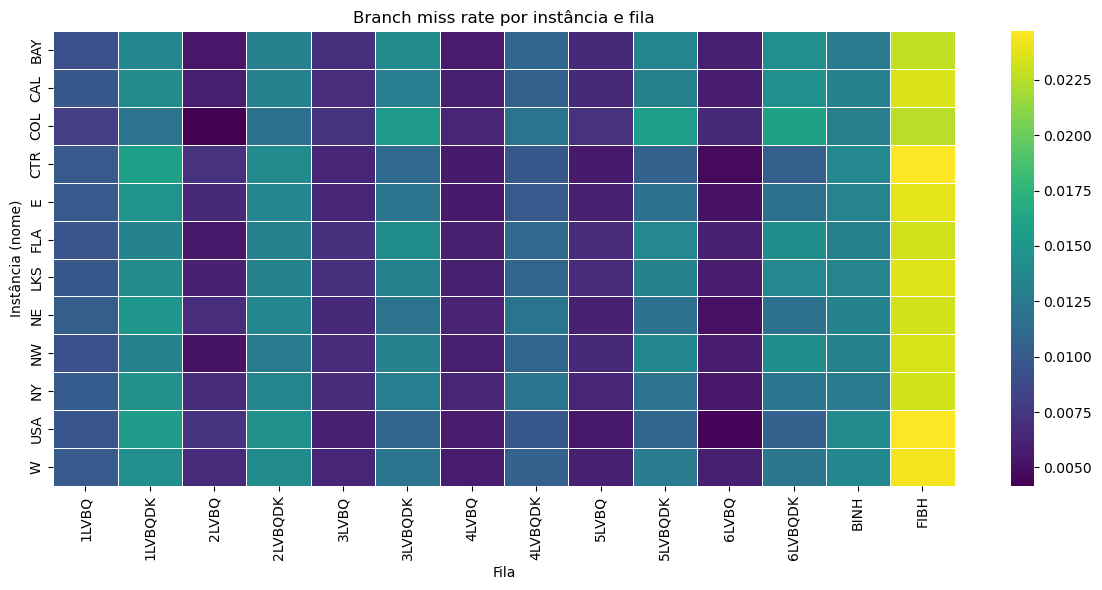

In [176]:

# ===== métrica escolhida =====
df_plot = df_branches.copy()

df_plot["miss"] = df_plot["bm_mean"]

# ===== pivot =====
heat = df_plot.pivot(index="nome", columns="fila", values="bm_mean")

# ===== plot =====
plt.figure(figsize=(12, 6))

sns.heatmap(
    heat,
    cmap="viridis",
    linewidths=0.5,
    linecolor="white"
)

plt.title("Branch miss rate por instância e fila")
plt.xlabel("Fila")
plt.ylabel("Instância (nome)")

plt.tight_layout()
plt.show()

## Instruções em CPU

In [177]:
df_inst = df_tcache[
    ['nome', 'n', 'c', 'fila', 'inst']
].copy()
df_inst = (
    df_inst.groupby(['nome', 'fila'], as_index=False)
      .agg(
           inst_mean=('inst', 'mean'),
           inst_std =('inst', 'std'),
           inst_var =('inst', 'var'),
           n=('n', 'first'),
      )
)
df_inst['inst_cv'] = df_inst['inst_std'] / df_inst['inst_mean']
df_inst

,nome,fila,inst_mean,inst_std,inst_var,n,inst_cv
0,BAY,1LVBQ,5.099865e+08,1.362368e+07,1.856047e+14,321270,0.026714
1,BAY,1LVBQDK,3.471308e+08,1.144046e+07,1.308842e+14,321270,0.032957
2,BAY,2LVBQ,6.786701e+08,2.107763e+07,4.442665e+14,321270,0.031057
3,BAY,2LVBQDK,4.114311e+08,6.808503e+06,4.635572e+13,321270,0.016548
4,BAY,3LVBQ,5.854865e+08,1.150025e+07,1.322557e+14,321270,0.019642
...,...,...,...,...,...,...,...
163,W,5LVBQDK,9.878128e+09,1.164597e+07,1.356286e+14,6262104,0.001179
164,W,6LVBQ,1.274413e+10,6.570731e+07,4.317451e+15,6262104,0.005156
165,W,6LVBQDK,1.001791e+10,1.520102e+07,2.310709e+14,6262104,0.001517
166,W,BINH,1.631324e+10,2.353405e+08,5.538517e+16,6262104,0.014426


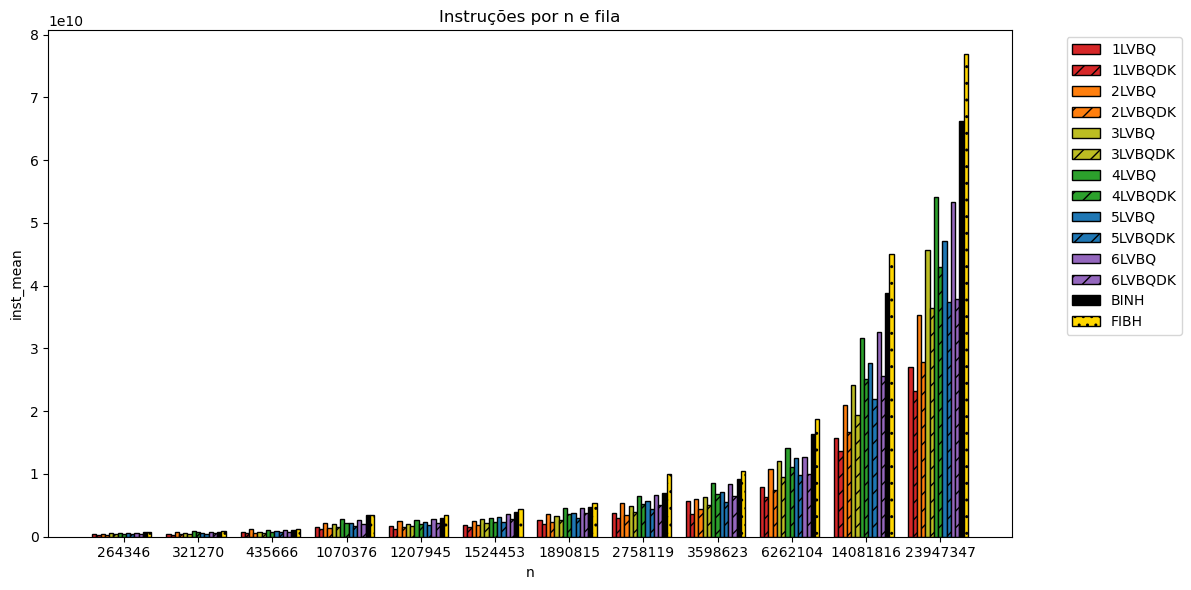

In [178]:
pivot = df_inst.pivot_table(
    index="n",
    columns="fila",
    values="inst_mean", 
    aggfunc="first"
)

n_vals = pivot.index.to_list()
filas = pivot.columns.to_list()

x = np.arange(len(n_vals))
width = 0.8 / len(filas)

# 🎨 cores por número da fila (LVBQ)
colors = {
    "1": "tab:red",
    "2": "tab:orange",
    "3": "tab:olive",
    "4": "tab:green",
    "5": "tab:blue",
    "6": "tab:purple",
}

plt.figure(figsize=(12, 6))

for i, fila in enumerate(filas):

    # ===== HEAPS (se existirem) =====
    if "BINH" in fila:
        color = "black"
        hatch = "xx"
        
    elif "FIBH" in fila:
        color = "gold"
        hatch = ".."

    # ===== LVBQ / LVBQDK =====
    else:
        m = re.match(r"\d+", fila)
        num = m.group() if m else None

        color = colors.get(num, "tab:gray")

        # DK com padrão
        hatch = "//" if "LVBQDK" in fila else None

    plt.bar(
        x + i * width,
        pivot[fila].values,
        width,
        label=fila,
        color=color,
        hatch=hatch,
        edgecolor="black"
    )

plt.xticks(x + width * len(filas) / 2, n_vals)
plt.xlabel("n")
plt.ylabel("inst_mean")
plt.title("Instruções por n e fila")
plt.legend(bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

## Cache miss Rate

In [179]:
# Miss Rate (misses/chamadas)
df_l1 = df_tcache[
    ['nome', 'fila', 'l1_miss', 'l1_ac']
].copy()
ac_safe = df_l1["l1_ac"].replace(0, np.nan)
df_l1['l1_miss_rate'] = df_l1['l1_miss'] / ac_safe

# Agregar
df_l1 = (
    df_l1.groupby(['nome', 'fila'], as_index=False)
      .agg(
           l1_mr_mean=('l1_miss_rate', 'mean'),
           l1_mr_std =('l1_miss_rate', 'std'),
           l1_mr_var =('l1_miss_rate', 'var'),
      )
)
df_l1['l1_mr_cv'] = df_l1['l1_mr_std'] / df_l1['l1_mr_mean']
df_l1

,nome,fila,l1_mr_mean,l1_mr_std,l1_mr_var,l1_mr_cv
0,BAY,1LVBQ,0.014591,0.000171,2.935972e-08,0.011743
1,BAY,1LVBQDK,0.017309,0.000731,5.340860e-07,0.042220
2,BAY,2LVBQ,0.007616,0.000271,7.357734e-08,0.035617
3,BAY,2LVBQDK,0.012202,0.000714,5.102466e-07,0.058543
4,BAY,3LVBQ,0.006215,0.000372,1.385525e-07,0.059888
...,...,...,...,...,...,...
163,W,5LVBQDK,0.016056,0.000636,4.040624e-07,0.039591
164,W,6LVBQ,0.007877,0.000662,4.388798e-07,0.084100
165,W,6LVBQDK,0.015706,0.000687,4.722174e-07,0.043752
166,W,BINH,0.006344,0.000348,1.214399e-07,0.054931


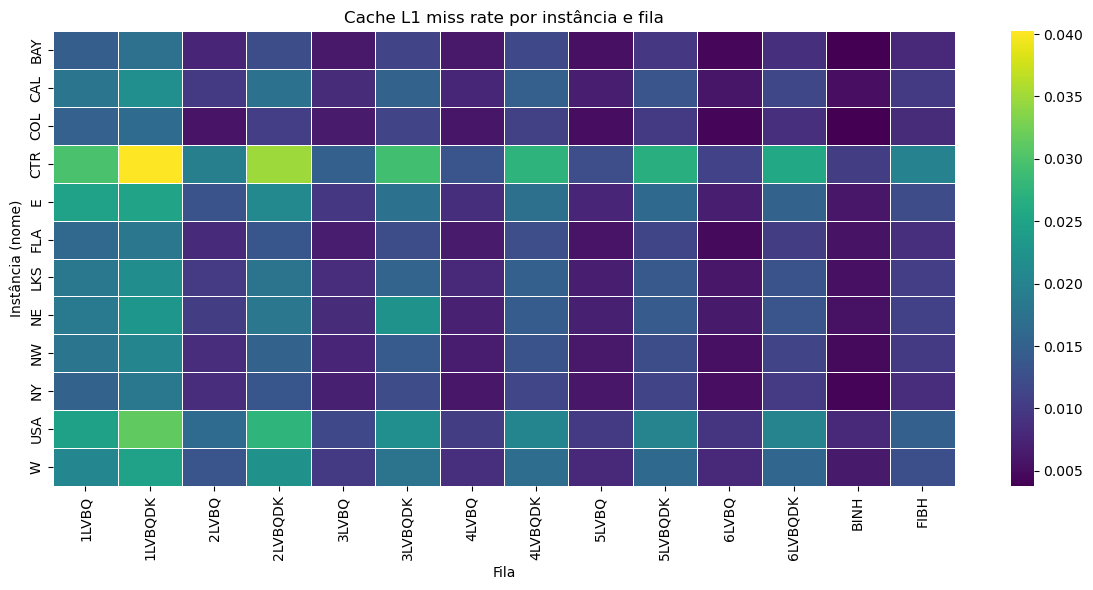

In [180]:

# ===== métrica escolhida =====
df_plot = df_l1.copy()

df_plot["miss"] = df_plot["l1_mr_mean"]

# ===== pivot =====
heat = df_plot.pivot(index="nome", columns="fila", values="l1_mr_mean")

# ===== plot =====
plt.figure(figsize=(12, 6))

sns.heatmap(
    heat,
    cmap="viridis",
    linewidths=0.5,
    linecolor="white"
)

plt.title("Cache L1 miss rate por instância e fila")
plt.xlabel("Fila")
plt.ylabel("Instância (nome)")

plt.tight_layout()
plt.show()

In [181]:
# Miss Rate (misses/chamadas)
df_llc = df_tcache[
    ['nome', 'fila', 'llc_miss', 'llc_ac']
].copy()
ac_safe = df_llc["llc_ac"].replace(0, np.nan)
df_llc['llc_miss_rate'] = df_llc['llc_miss'] / ac_safe

# Agregar
df_llc = (
    df_llc.groupby(['nome', 'fila'], as_index=False)
      .agg(
           llc_mr_mean=('llc_miss_rate', 'mean'),
           llc_mr_std =('llc_miss_rate', 'std'),
           llc_mr_var =('llc_miss_rate', 'var'),
      )
)
df_llc['llc_mr_cv'] = df_llc['llc_mr_std'] / df_llc['llc_mr_mean']
df_llc

,nome,fila,llc_mr_mean,llc_mr_std,llc_mr_var,llc_mr_cv
0,BAY,1LVBQ,0.384314,0.014226,0.000202,0.037016
1,BAY,1LVBQDK,0.464605,0.018915,0.000358,0.040712
2,BAY,2LVBQ,0.490539,0.016653,0.000277,0.033948
3,BAY,2LVBQDK,0.498640,0.016308,0.000266,0.032705
4,BAY,3LVBQ,0.472890,0.010254,0.000105,0.021684
...,...,...,...,...,...,...
163,W,5LVBQDK,0.343758,0.019736,0.000389,0.057412
164,W,6LVBQ,0.387378,0.039829,0.001586,0.102817
165,W,6LVBQDK,0.351054,0.023484,0.000551,0.066895
166,W,BINH,0.389021,0.019418,0.000377,0.049915


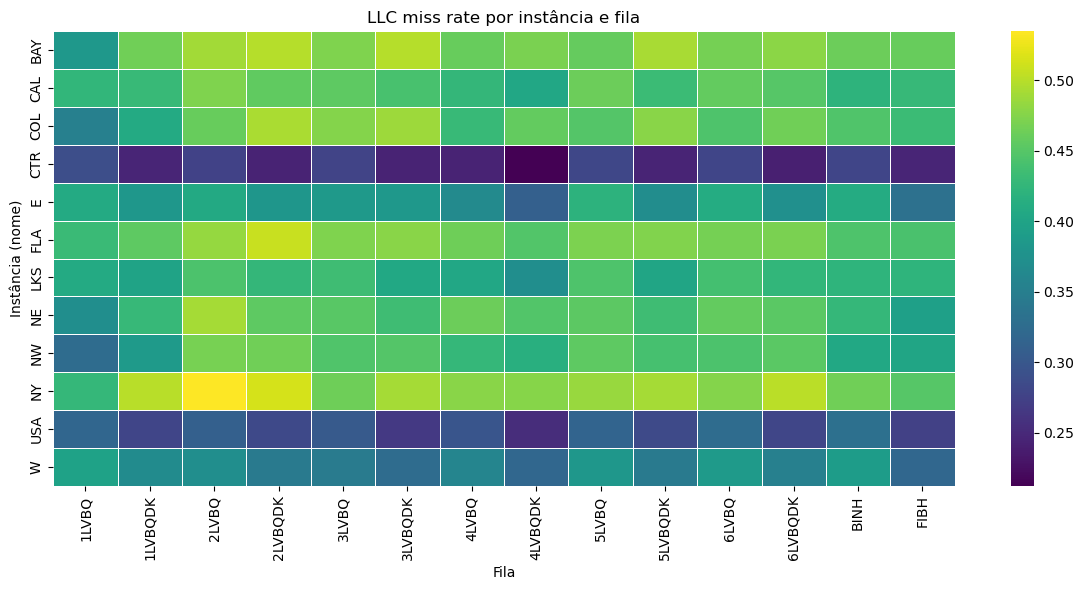

In [182]:

# ===== métrica escolhida =====
df_plot = df_llc.copy()

df_plot["miss"] = df_plot["llc_mr_mean"]

# ===== pivot =====
heat = df_plot.pivot(index="nome", columns="fila", values="llc_mr_mean")

# ===== plot =====
plt.figure(figsize=(12, 6))

sns.heatmap(
    heat,
    cmap="viridis",
    linewidths=0.5,
    linecolor="white"
)

plt.title("LLC miss rate por instância e fila")
plt.xlabel("Fila")
plt.ylabel("Instância (nome)")

plt.tight_layout()
plt.show()